predict the selling price of a used car based on features

get the data

In [1]:
import kagglehub 

path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

print("Path to dataset files:", path)


Path to dataset files: /Users/zainbabar/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4


In [2]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv("data/car-details-v4.csv")

In [4]:
data.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [5]:
data.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   str    
 1   Model               2059 non-null   str    
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   str    
 6   Transmission        2059 non-null   str    
 7   Location            2059 non-null   str    
 8   Color               2059 non-null   str    
 9   Owner               2059 non-null   str    
 10  Seller Type         2059 non-null   str    
 11  Engine              1979 non-null   str    
 12  Max Power           1979 non-null   str    
 13  Max Torque          1979 non-null   str    
 14  Drivetrain          1923 non-null   str    
 15  Length              1995 non-null   float64
 16  Width            

In [7]:
raw_data = data
data = data.dropna()

In [8]:
data.info()

<class 'pandas.DataFrame'>
Index: 1874 entries, 0 to 2057
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                1874 non-null   str    
 1   Model               1874 non-null   str    
 2   Price               1874 non-null   int64  
 3   Year                1874 non-null   int64  
 4   Kilometer           1874 non-null   int64  
 5   Fuel Type           1874 non-null   str    
 6   Transmission        1874 non-null   str    
 7   Location            1874 non-null   str    
 8   Color               1874 non-null   str    
 9   Owner               1874 non-null   str    
 10  Seller Type         1874 non-null   str    
 11  Engine              1874 non-null   str    
 12  Max Power           1874 non-null   str    
 13  Max Torque          1874 non-null   str    
 14  Drivetrain          1874 non-null   str    
 15  Length              1874 non-null   float64
 16  Width               18

In [9]:
data.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


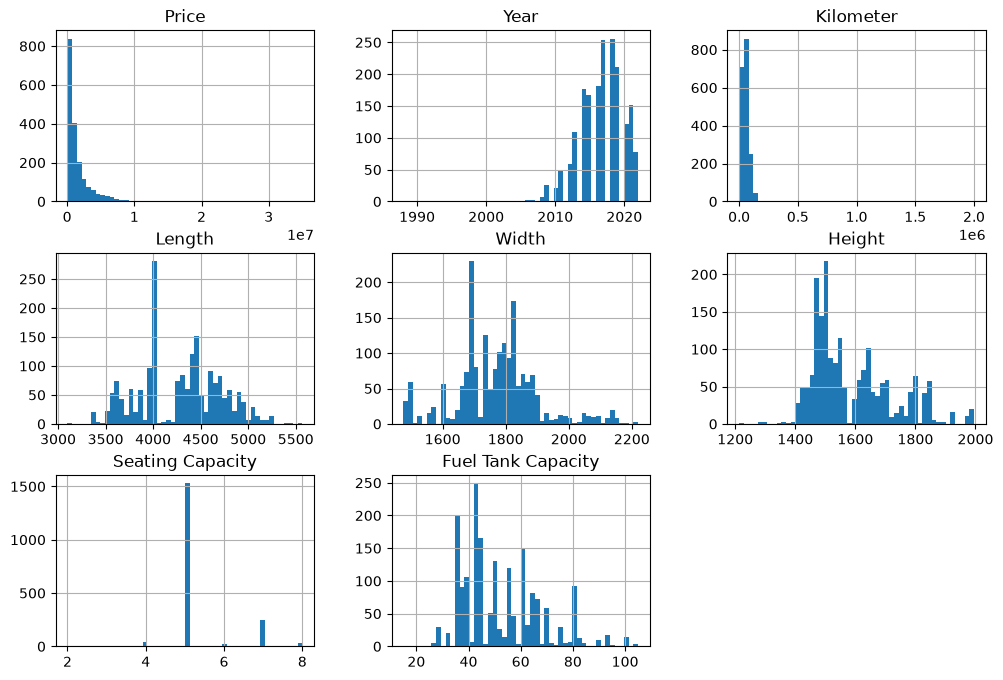

In [10]:
import matplotlib.pyplot as plt

data.hist(bins=50, figsize=(12,8))
plt.show()

split into train/test set, skip stratification for now

In [11]:
features = data.drop(columns=["Price"])
prices = data["Price"]

from sklearn.model_selection import train_test_split

In [12]:

features_train, features_test, prices_train, prices_test = train_test_split(features, prices, test_size=0.2, random_state=42)
train_set = pd.concat([features_train, prices_train], axis=1)

look for correlations

In [13]:
corr_matrix = train_set.corr(numeric_only=True)

In [14]:
corr_matrix["Price"]

Year                  0.318989
Kilometer            -0.143158
Length                0.611532
Width                 0.596076
Height                0.107755
Seating Capacity      0.020716
Fuel Tank Capacity    0.599215
Price                 1.000000
Name: Price, dtype: float64

lookings like strongest numeric indicator is the length/width/fuel tank, implying that larger cars are more expensive. then year. 

but, intuitively we know that the biggest driving factor would probably be the make/model, i.e. luxury cars cost more

In [15]:
counts = train_set["Make"].value_counts()
rare = counts[counts < 10].index # makes that don't appear very often, not very useful for use
train_set["Make"] = train_set["Make"].replace(rare, "Other") # combine all rare makes into an "other" category

In [16]:
train_set = pd.get_dummies(train_set, columns=["Make"], drop_first=True)
train_set.head()

,Model,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,...,Make_Maruti Suzuki,Make_Mercedes-Benz,Make_Nissan,Make_Other,Make_Renault,Make_Skoda,Make_Tata,Make_Toyota,Make_Volkswagen,Make_Volvo
264,Wagon R LXi Minor,2009,39586,Petrol,Manual,Ranchi,Red,First,Individual,1061 cc,...,True,False,False,False,False,False,False,False,False,False
1326,Alto 800 Lx CNG,2017,45000,CNG,Manual,Pune,Silver,First,Individual,796 cc,...,True,False,False,False,False,False,False,False,False,False
1042,Cooper D 3 Door,2018,17000,Diesel,Automatic,Delhi,Green,First,Individual,1496 cc,...,False,False,False,True,False,False,False,False,False,False
794,GLE 300d 4MATIC LWB,2020,18000,Diesel,Automatic,Delhi,Bronze,First,Individual,1950 cc,...,False,True,False,False,False,False,False,False,False,False
1997,City 1.5 E MT,2013,86000,Petrol,Manual,Mumbai,Purple,Second,Individual,1497 cc,...,False,False,False,False,False,False,False,False,False,False


now the make is one hot encoded. 

what else can we do with the data? thinking about it intutively, some things that probably don't affect the price would be seller type, colour, location. engine size could be useful, but we need to convert it to a numeric value, and owner could also be useful. tranmission and fuel type are debatable. 

In [18]:
train_set = pd.get_dummies(train_set, columns=["Transmission"], drop_first=True) 
train_set = train_set.drop(columns=["Color"])

In [21]:
train_set["Owner"].value_counts()

Owner
First               1204
Second               255
Third                 24
UnRegistered Car      16
Name: count, dtype: int64

In [22]:
owner_map = {"First": 1, "Second": 2, "Third": 3, "UnRegistered Car": 4}
train_set["Owner"] = train_set["Owner"].map(owner_map)

some more data cleaning, auto cars would prob cost more than the manuals so one hot that, and drop colour. ordinal encode owners, with unreg being 4, since an unreigstered car would prob cost less.

In [24]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 1499 entries, 264 to 1240
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Model                1499 non-null   str    
 1   Year                 1499 non-null   int64  
 2   Kilometer            1499 non-null   int64  
 3   Fuel Type            1499 non-null   str    
 4   Location             1499 non-null   str    
 5   Owner                1499 non-null   int64  
 6   Seller Type          1499 non-null   str    
 7   Engine               1499 non-null   str    
 8   Max Power            1499 non-null   str    
 9   Max Torque           1499 non-null   str    
 10  Drivetrain           1499 non-null   str    
 11  Length               1499 non-null   float64
 12  Width                1499 non-null   float64
 13  Height               1499 non-null   float64
 14  Seating Capacity     1499 non-null   float64
 15  Fuel Tank Capacity   1499 non-null   float64
 16  Pr

In [ ]:
train_set.drop(columns=["Fuel Type"])